## **source cell :**

In [47]:
import numpy as np
import random as rd
import pandas as pd
import math
import secrets as st
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter

time_step = 1
v = 0.3
def initialize() :
    global N, L, x_positions, y_positions, directions, order_parameters
    x_positions = [ np.round(np.random.uniform(0, L, N), 2) ]
    y_positions = [ np.round(np.random.uniform(0, L, N), 2) ]
    directions = [ np.round(np.random.uniform(0, 2*np.pi, N), 2) ]

    #order parameter
    v_xs = np.cos(directions[-1])
    v_ys = np.sin(directions[-1])
    order_parameter = ( np.mean(v_xs)**2 + np.mean(v_ys)**2 )**0.5
    order_parameters = [order_parameter]

def update() :
    global R, v, etta, new_xs, new_ys, new_dirs, order_parameter
    xs = x_positions[-1]
    ys = y_positions[-1]
    v_xs = v*np.cos(directions[-1])
    v_ys = v*np.sin(directions[-1])
    #positions update
    new_xs = (xs + time_step*v_xs)%L
    new_ys = (ys + time_step*v_ys)%L
    #direction update
    new_dirs = []
    for n in range(N) :
        dx = xs - xs[n]
        dy = ys - ys[n]
        # applying periodic boundary condition
        dx = (dx+L/2)%L - L/2
        dy = (dy+L/2)%L - L/2

        neighboring_mask = (dx**2+dy**2)**0.5 < R
        n_neighbors_mean_vx = np.mean( v_xs[neighboring_mask] )
        n_neighbors_mean_vy = np.mean( v_ys[neighboring_mask] )

        if not n_neighbors_mean_vx == 0 :
            new_dir = (math.atan2( n_neighbors_mean_vy, n_neighbors_mean_vx )
                     + rd.uniform(-etta/2, etta/2))
        else :
            new_dir = np.pi/2 if n_neighbors_mean_vy > 0 else -np.pi/2
        new_dirs.append(new_dir%2*np.pi)
    #order parameter
    v_xs = v * np.cos(new_dirs)
    v_ys = v * np.sin(new_dirs)
    order_parameter = np.sqrt( np.mean(v_xs)**2 + np.mean(v_ys)**2 )/v

def observe() :
  global x_positions, y_positions, directions, order_parameters
  x_positions.append(new_xs)
  y_positions.append(new_ys)
  directions.append(new_dirs)
  order_parameters.append(order_parameter)

def animation() :
    fig, ax = plt.subplots()
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    quiver = ax.quiver(x_positions[0], y_positions[0],
                        np.cos(directions[0]), np.sin(directions[0]),
              color='blue', scale=20, width=0.005)
    individual_arrow = ax.quiver([x_positions[0][individual_particle]],
                                [y_positions[0][individual_particle]],
                                [np.cos(directions[0][individual_particle])],
                                [np.sin(directions[0][individual_particle])],
                                color='red', scale=20, width=0.005)
    def update0(frame):
      quiver.set_offsets(np.column_stack((x_positions[frame], y_positions[frame])))
      quiver.set_UVC(np.cos(directions[frame]), np.sin(directions[frame]))
      individual_arrow.set_offsets(np.column_stack((
                [x_positions[frame][individual_particle]],
                [y_positions[frame][individual_particle]])))
      individual_arrow.set_UVC([np.cos(directions[frame][individual_particle])],
                               [np.sin(directions[frame][individual_particle])])
      return quiver, individual_arrow,
    ani = FuncAnimation(fig, update0, frames=100, interval=300, blit=True)
    ax.set_title(f"N={N}   L={L}   v={v}   R={R}   etta={etta}   T=100")
    ani.save(f"../../animations/sample{sample}.mp4")

def run_simulation() :
  global directions, order_parameters
  initialize()
  for t in range(100) :
    update()
    observe()
    if 1000*t%n_samples == 0 :
        animation()

### **parameter combinations**

In [43]:
L = 5
Rs = np.array([0.5, 1, 1.5, 2, 2.5])
ettas = np.array([0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5])
densities = np.linspace(1, 40, 2500)
Ns = (L**2)*densities
v = 0.3

In [44]:
R_etta_density_combinations = list(itertools.product(Rs, ettas, densities))

In [45]:
print(len(R_etta_density_combinations))

100000


### **data producing**

MovieWriter ffmpeg unavailable; using Pillow instead.


ValueError: unknown file extension: .mp4

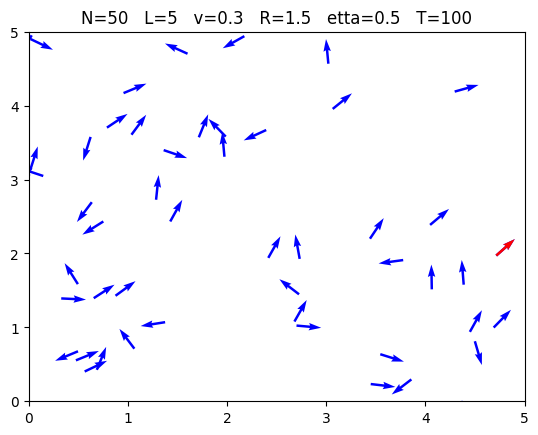

In [50]:
n_samples = 50
count = n_samples
dataset = []
N = 50
L = 5
etta = 0.5
R = 1.5
density = 50/(1.5**2)
for sample in range(1, n_samples) :
  global N, L, density, R, etta
  individual_particle = rd.randint(0, N-1)
  run_simulation()
  T = len(order_parameters)
  individuals_dirs = [ i[individual_particle] for i in directions ]
  data = [order_parameters[-1],
          order_parameters,
          individuals_dirs,
          density,
          R,
          etta]
  dataset.append(data)
  print(count)
  count-=1

In [49]:
!pip install ffmpeg-python

  Using cached ffmpeg_python-0.2.0-py3-none-any.whl.metadata (1.7 kB)
  Using cached future-1.0.0-py3-none-any.whl.metadata (4.0 kB)
Using cached ffmpeg_python-0.2.0-py3-none-any.whl (25 kB)
Using cached future-1.0.0-py3-none-any.whl (491 kB)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
